# Ames House Price Prediction

End-to-End Regression Project

This project develops a complete machine learning pipeline for predicting
house sale prices using the Ames Housing dataset.

## Project Stages
1. Exploratory Data Analysis
2. Data Cleaning and Feature Engineering
3. Regression Modeling
4. Model Evaluation and Interpretation

In [25]:
import pandas as pd

df = pd.read_csv("/content/train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [27]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [28]:
correlations = df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

correlations

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


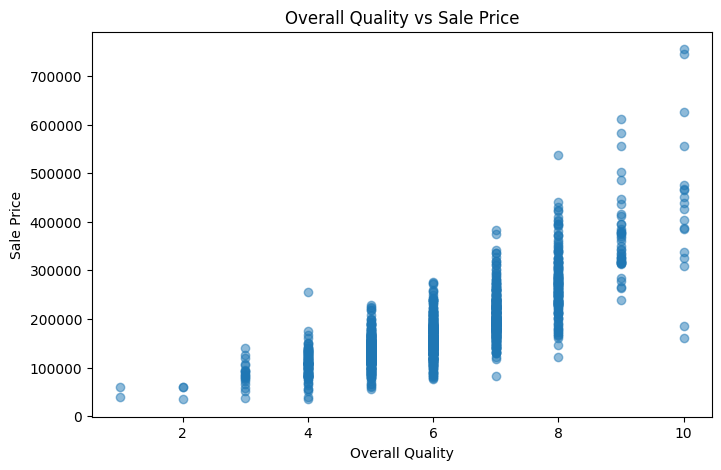

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["OverallQual"], df["SalePrice"], alpha=0.5)
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()


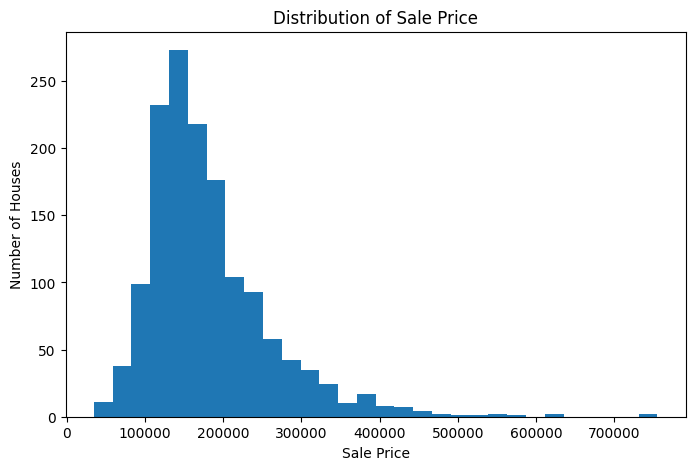

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Price")
plt.show()

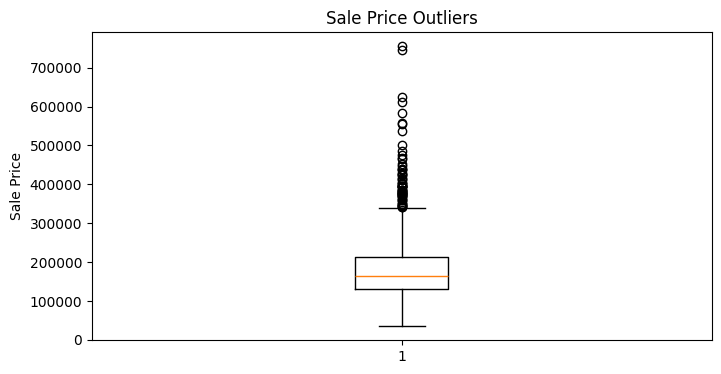

In [31]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["SalePrice"])
plt.ylabel("Sale Price")
plt.title("Sale Price Outliers")
plt.show()

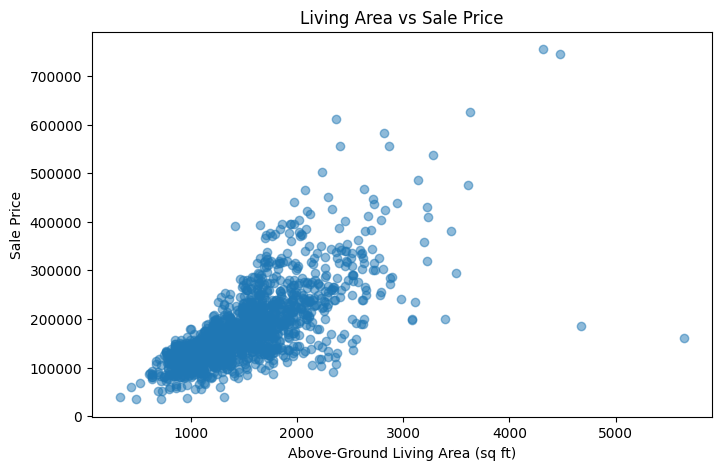

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [34]:
top_correlations = correlations.drop("SalePrice").abs().sort_values(ascending=False).head(10)

top_correlations

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


In [35]:
data = df.copy()

print("Original shape:", data.shape)

Original shape: (1460, 81)


In [36]:
data = data.drop(columns=["Id"])

print("New shape:", data.shape)

New shape: (1460, 80)


In [37]:
data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]

data["TotalBathrooms"] = (
    data["FullBath"]
    + 0.5 * data["HalfBath"]
    + data["BsmtFullBath"]
    + 0.5 * data["BsmtHalfBath"]
)

data["HouseAge"] = data["YrSold"] - data["YearBuilt"]

data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]

print("New shape:", data.shape)

New shape: (1460, 84)


In [38]:
data[["TotalSF", "TotalBathrooms", "HouseAge", "RemodAge"]].describe()

,TotalSF,TotalBathrooms,HouseAge,RemodAge
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,36.547945,22.950000
std,821.714421,0.785399,30.250152,20.640653
min,334.000000,1.000000,0.000000,-1.000000
25%,2009.500000,2.000000,8.000000,4.000000
50%,2474.000000,2.000000,35.000000,14.000000
75%,3004.000000,2.500000,54.000000,41.000000
max,11752.000000,6.000000,136.000000,60.000000


In [39]:
data.loc[data["RemodAge"] < 0, ["YearRemodAdd", "YrSold", "RemodAge"]]


,YearRemodAdd,YrSold,RemodAge
523,2008,2007,-1


In [40]:
data.loc[data["RemodAge"] < 0, "RemodAge"] = 0

print("Negative RemodAge values:", (data["RemodAge"] < 0).sum())

Negative RemodAge values: 0


In [41]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [42]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "MasVnrType", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "BsmtQual", "BsmtCond"
]

data[none_cols] = data[none_cols].fillna("None")

print("Remaining missing values:", data.isnull().sum().sum())

Remaining missing values: 349


In [43]:
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

print("Missing LotFrontage:", data["LotFrontage"].isnull().sum())

Missing LotFrontage: 0


In [44]:
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

print("Missing GarageYrBlt:", data["GarageYrBlt"].isnull().sum())
print("Missing MasVnrArea:", data["MasVnrArea"].isnull().sum())

Missing GarageYrBlt: 0
Missing MasVnrArea: 0


In [45]:
print(data["Electrical"].value_counts())

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64
